## **Log returns, stationarity and some statistical moments**

This jupyter lab file covers some necessities in Econometrics and Commodity analysis. 
Log returns are a natural starting point, they are found by taking the difference between
logged Closing prices. Log returns are useful for a variety of reasons as follows: 

- Additive over time, rather than multiplicative such as relative returns
- Often help data exhibit 'staionarity' which will be covered later in this file
- Log returns are scale free and have the same interpretation regradless of metric/currency 

In [161]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Set-up as data instead of long name
data = pd.read_csv("Cl_4M_24_TO_MAY26.csv")

The above simply reads-in the data that was extracted using **getting_Cl.ipynb**, readers 
who have not already read this are recomended to start here. The link to the Jupyter lab reader is here: 

https://github.com/Alexandros-A-P/Commodity-Suite-in-Python/blob/main/PART1_getting_data_Closing.ipynb

In [162]:
# Log returns

rt_GC = np.log(data['Gold Closing'] / data['Gold Closing'].shift(1))
rt_SI = np.log(data['Silver Closing'] / data['Silver Closing'].shift(1))
rt_PL = np.log(data['Platinum Closing'] / data['Platinum Closing'].shift(1))
rt_HG = np.log(data['Copper Closing'] / data['Copper Closing'].shift(1))
Date = data['Date']

# Turn into CSV 31/05/2024 to 31/05/2026 and then remove Nan (First row) 
Data = pd.DataFrame({'GC rt': rt_GC, 'SI rt': rt_SI, "PL rt": rt_PL, "HG rt": rt_HG, "Date": Date})
Data = Data.dropna()

# Create CSV
Data.to_csv("Logr_4M_24_TO_MAY26.csv")

The forumas for log returns **np.log(data['Asset'] / data['Asset'].shift(1))** is common practice 
in python although there are many ways to get log returns. However, this is the most convenient. 

Because the log return for row 1 of the data has no previous trading day in our imported dataset,
this value will be missing since the log return can only be calculated when using the previous day. 
As such, it is important to remove this missing/Nan value from the dataset, so naturally, **Data.dropna()**
is used to 'clean' the dataset from missing observations. 

In [163]:
# Run ADF test to check if log returns follow stationary process

from statsmodels.tsa.stattools import adfuller

adfuller(Data['GC rt']) # tiny value, sig to 0.01%
adfuller(Data['SI rt']) # zero
adfuller(Data['PL rt']) # zero
adfuller(Data['HG rt']) # zero

(np.float64(-24.57150480206635),
 0.0,
 0,
 500,
 {'1%': np.float64(-3.443496379464),
  '5%': np.float64(-2.8673378563200003),
  '10%': np.float64(-2.569858036)},
 np.float64(-2345.1072022907565))

**Stationarity** can be tested for using an Augmented Dickey Fuller (or ADF) test. This property 
is important as it ensures there is no long term trend in the data. Otherwise different observations
belong to different distributions which makes modelling unfeasible. Fortunately, using a log return transformation ensures that all of the commodity data is stationary. 

**Note:** The p-value may often appear as zero (0), but this is not the true p-value. Instead, the value 
is negligeably larger than zero so Python returns zero. As such, the null hypothesis (No Stationarity) 
has sufficient evidence for rejection and the analysis may continue. 

## **Visualising log returns from 03/06/2024 to 29/05/2026**

- Time series plots of Gold, Silver, Platinum and Copper futures
- Red line shows the median value for the respective commodity future
- Y-axes are not on the same scale, each plot should be investigated individually 

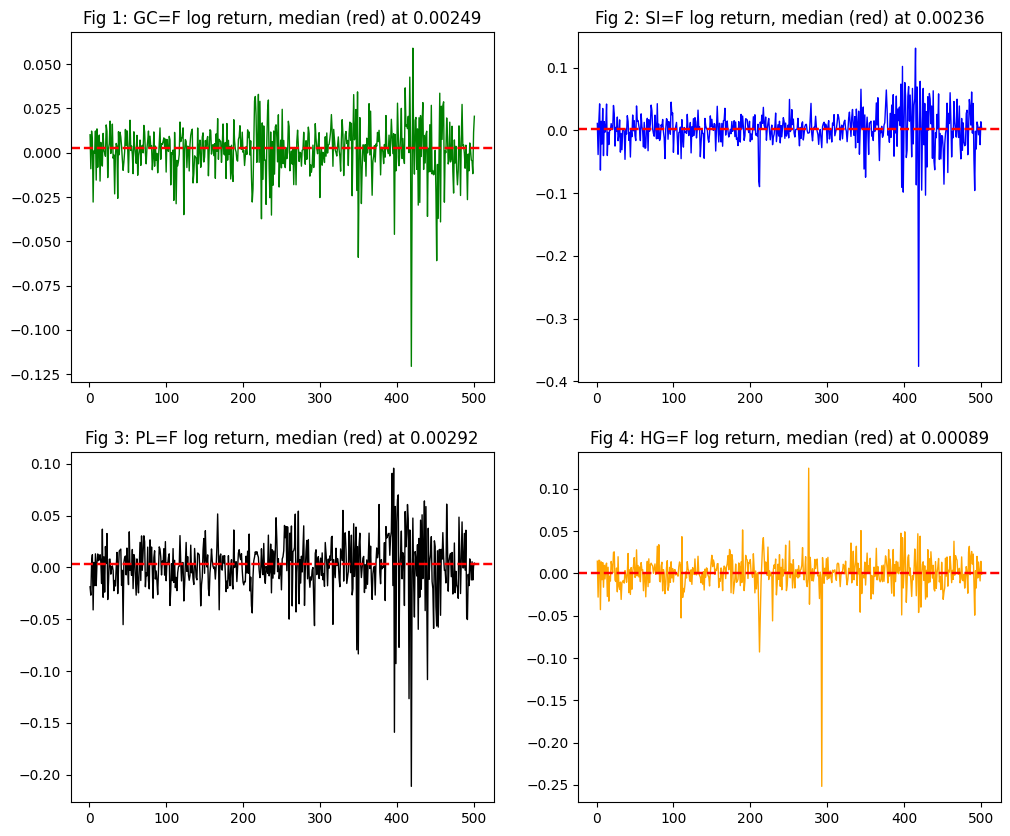

In [166]:
# Visualise the four commodities and their respective log returns over time

fig, axs = plt.subplots(2,2 , figsize = (12, 10))
axs[0,0].plot(Data['GC rt'], c = "green", lw =1)
axs[0,0].set_title("Fig 1: GC=F log return, median (red) at 0.00249")
axs[0,0].axhline(y = 0.002492660, c = "red", linestyle = "--", lw = 1.75)

axs[0,1].plot(Data['SI rt'], c = "blue", lw =1)
axs[0,1].set_title("Fig 2: SI=F log return, median (red) at 0.00236")
axs[0,1].axhline(y = 0.002369823, c = "red", linestyle = "--", lw = 1.75)

axs[1,0].plot(Data['PL rt'], c = "black", lw =1)
axs[1,0].set_title("Fig 3: PL=F log return, median (red) at 0.00292")
axs[1,0].axhline(y = 0.0029248340, c = "red", linestyle = "--", lw = 1.75)

axs[1,1].plot(Data['HG rt'], c = "orange", lw =1)
axs[1,1].set_title("Fig 4: HG=F log return, median (red) at 0.00089")
axs[1,1].axhline(y = 0.0008961737, c = "red", linestyle = "--", lw = 1.75)

An encouraging sign in time series is when the (log) returns do not show any clear trend/drift. In this case, 
all the figures demonstrate fluctuations around zero. But no consistently visible deviations away, howevever, readers must note that graphs **never** formally provide proof of staionarity. 

Hence the need for formal testing, this applies to all statistical analysis, inferences should not be made from graphs alone. 

**Some useful statistical moments** 

- Mean for finding expected value, although in non-paramteric samples is not robust to skewed data.
- Median as the prefered measure of central tendancy in non-parametric analysis as it is robust to skewed data.
- Standard deviation as the average deviation from the expected value.
- Skewness to determine the direction and magnitude of asymetry (typically negative in financial data).
- Excess Kurtosis for assessing the degree of heavy tailedness, (excess Kurtosis is simply Kurtosis - 3). Since it is widely known that the normal distribution has a kurtosis of 3. By subtracting this, the result effectively demonstrates the extra frequency of tail (extreme) events such as exceptionally high returns or losses.   


For now, only the asymetry and heavy tailedness will be considered.

It is also worth noting that these statitsical moments are all random variables and are subject to change over time. So these point estimates are only accurate for the specific data **(Logr_4M_24_TO_MAY26.csv)**, however, the results do show values that are typical in commodity data.

In [174]:
# Create density plots and analyse statistics (mean, median, std, skewness and kurtosis)
from scipy.stats import skew
from scipy.stats import kurtosis

# Skewness of each Commodity
Skew_GC = skew(Data['GC rt'], bias = False)
Skew_SI = skew(Data['SI rt'], bias = False)
Skew_PL = skew(Data['PL rt'], bias = False)
Skew_HG = skew(Data['HG rt'], bias = False)

# Kurtosis of each Commodity
Kurt_GC = kurtosis(Data['GC rt'], bias = False)
Kurt_SI = kurtosis(Data['SI rt'], bias = False)
Kurt_PL = kurtosis(Data['PL rt'], bias = False)
Kurt_HG = kurtosis(Data['HG rt'], bias = False)

#skew_GC = skew(data['GC rt'])
#kurt_GC = kurtosis(data['GC rt'])

**Brief commentary on each commodity**

- **Gold futures** have a skewness of roughly -1.509 illustrating that there are disproportionately more frequent/severe extreme losses compared to extreme gains, nevertheless, Gold remains the least volatile of the four commodities as remains the 'safe haven' investment choice.
- Yet, the excess Kurtosis of Gold is almost 8 which is vastly more than if the data was normally distributed. Instead, an suggestion would be to model Gold future log returns with the Student-t or Cauchy distributions which account for larger 'tails'.

- **Silver futures** suffer from a greater degree of asymetry in the negative direction with a skewness of -3.134. In other words, Silver has more extreme 'bad days' compared to Gold.
-  The excess Kurtosis of Silver is alarmingly high at 32.419 indicating that the asset has considerably more extreme days than Gold.

- **Platinum** skewness at -1.533 is consistent with the previous precious metals exhibiting asymetry and a tendancy to have either more extreme/frequent losses.
- The excess Kurtosis of Platinum is just over 7 (7.007) which although more stable than Gold and Silver is still too high to model the asset with the normal distribution by a grand margin.

- **Copper** along with Silver had a large, negative asymetry at -3.206 making it the most negative of the four. This result may be less surprising as Copper is a **'base'** metal meaning it is used in industrial processes in areas like electronics manufacturing which has suffered from a drop in global demand due to the 'Cost-of-living' crises and US/Iran tension-induced uncertainty.
- Excess Kurtosis was at 39.588 which is comfortably the most extreme of the four commodities. This is a valuable insight into the high volatility of the base metal.    

**Closing remarks for this section**

Gold and Platinum were the safer futures to hold as they had less severe asymetries below zero and significantly lower Kurtosis. The former meant that in the period of study, exteme losses were less frequent and severe than for Copper and Silver while the latter concludes that (Gold and Platinum) had more calm volatility. 

**Economic interpretation** 

Gold and to a smaller extent platinum, behave like 'hedges' to inflation (Smales, 2014). Working as a safe storage of value when currency is decaying. On the other hand, Copper which is used in industrial processes has felt the brunt of low global demand (JPMorgan insights). 

The analysis is still missing two key aspects of risk analysis, firstly the issue of volatility clustering when extreme days follow other extreme days, and secondly, volatility persistence when 'shocks' continue to impact markets over a period of time. This motivates a deeper layer of analysis which employes the ARCH/GARCH family of models. 

**Citations and links**

Smales, L.A., 2014. News sentiment in the gold futures market. Journal of Banking & Finance, 49, pp.275-286.

https://www.jpmorgan.com/insights/global-research/commodities/copper-outlook.

https://www.sciencedirect.com/science/article/pii/S0378426614003069?casa_token=8kJhjxLSujwAAAAA:jII3wMbLo7WEnE6N8gStzqV0qsjs_ubvrG0A7HkxNRFumgfD-V_kAaygFAc7bAk2s3HBinYvkA